# Gravitational Sonar v21 — JAX + LM launch notebook

Adam → short BFGS continuation → exact-residual Levenberg–Marquardt.

All post-training diagnostics are JAX/NumPy; legacy PyTorch cells removed.


## Setup

In [ ]:
# Colab already ships JAX. This only supplies the original custom BFGS patch.
!wget -q -nc https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [ ]:
import math
import os
import time
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)  # needed by the original BFGS handoff
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.optimize import minimize

print("JAX:", jax.__version__)
print("Devices:", jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend. In Colab select Runtime > Change runtime type > GPU.")

Array = jax.Array

JAX: 0.7.2
Devices: [CudaDevice(id=0)]


## Data and physical inputs

In [ ]:
DATA_DIR = Path("/content")
FILE_TAG = "Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483"

t_true, hp_np = np.loadtxt(DATA_DIR / f"waveform_real_{FILE_TAG}.txt", unpack=True)
_, hc_np = np.loadtxt(DATA_DIR / f"waveform_imag_{FILE_TAG}.txt", unpack=True)
soln_true = np.loadtxt(DATA_DIR / f"solution_{FILE_TAG}.txt", unpack=True)

rp_true = 10.0
ra_true = 14.0
a_true = 0.9
theta_min_true = math.pi / 4
theta_observed = jnp.asarray([math.pi / 4], dtype=jnp.float32)

# Exact original grid: 1,000 coordinate-time samples over [0, 1260].
t_full = jnp.linspace(0.0, 1260.0, 1000, dtype=jnp.float32)
hp_full = jnp.asarray(hp_np[: len(t_full)], dtype=jnp.float32)[None, :]
hc_full = jnp.asarray(hc_np[: len(t_full)], dtype=jnp.float32)[None, :]

dt_np = np.diff(np.asarray(t_full))
assert np.allclose(dt_np, dt_np[0], rtol=1e-3), "t must be uniform"
print("samples:", len(t_full), "observers:", len(theta_observed))

samples: 1000 observers: 1


## 69-parameter metric network and unchanged ansatz

In [ ]:
def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }


def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]


def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))


def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)


def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


params = init_network(random.PRNGKey(0))
flat0, _ = ravel_pytree(params)
assert flat0.size == 69
print("parameters:", flat0.size, "test output:", network_apply(params, jnp.array([2.0, 1.57])))

parameters: 69 test output: [-0.61378847  0.65292454  0.55026903 -0.2847634  -0.58163525]


In [ ]:
R_LO, R_HI = 6.2, 20.0
TH_LO, TH_HI = 0.1, math.pi/2 - 0.1

def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

def encode_ic(r, theta, pt, Lz):
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        inv_softplus(-pt),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def decode_ic(z):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    pt = -jax.nn.softplus(z[2])
    Lz = jax.nn.softplus(z[3])
    return jnp.asarray([0., r, theta, 0., pt, 0., 0., Lz])

params = {
    "metric": params,
    "ic": encode_ic(9.0, 0.90, -0.90, 2.30),
}

assert ravel_pytree(params)[0].size == 73

## Initial conditions — unchanged Kerr map, evaluated once outside JIT

In [ ]:
def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q


def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    return np.asarray([0.0, r_p, theta_min, 0.0, -E, 0.0, 0.0, Lz])


# solve_ELQ is not part of training AD: original ICs are fixed.
U0 = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
print("u0:", U0)

u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]


## Hamiltonian and RK4 — same equations, `lax.scan` time loop

In [ ]:
I4 = jnp.eye(4)
Z4 = jnp.zeros((4, 4))
SYMPLECTIC = jnp.block([[Z4, I4], [-I4, Z4]])
DISSIPATION = -10e-4 * jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1])


def hamiltonian_network(params, state):
    _, r, theta, _, p_t, p_r, p_theta, p_phi = state
    inv_g = jnp.linalg.inv(metric_from_network(params, r, theta))
    p = jnp.stack((p_t, p_r, p_theta, p_phi))
    return 0.5 * p @ inv_g @ p


def H_function(params, state):
    grad_H = jax.grad(hamiltonian_network, argnums=1)(params, state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def hamiltonian_kerr(state):
    inv_g = jnp.linalg.inv(Kerr(state[:4], a_true))
    return 0.5 * state[4:] @ inv_g @ state[4:]


def H_Kerr(state):
    grad_H = jax.grad(hamiltonian_kerr)(state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0


def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)


def integrate_network(params, y0, t_array):
    return integrate(lambda time, state: H_function(params, state), y0, t_array)


def integrate_kerr(y0, t_array):
    return integrate(lambda time, state: H_Kerr(state), y0, t_array)

## Numerical-kludge waveform — identical algebra, vectorized

In [ ]:
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2


def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))


def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)


def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q


def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)


def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)

## Curvature and boundary terms — full-grid `vmap`

In [ ]:
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)


def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4


def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))


R_INNER = jnp.logspace(math.log10(2.0), math.log10(20.0), 20)
R_OUTER = jnp.asarray([30.0, 50.0, 100.0, 200.0])
THETA_RICCI = jnp.linspace(math.pi / 20.0, math.pi / 2.0, 4)
RR, TT = jnp.meshgrid(jnp.concatenate((R_INNER, R_OUTER)), THETA_RICCI, indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size), RR.ravel(), TT.ravel(), jnp.zeros(RR.size)), axis=1)
BC_R = jnp.linspace(1.0, 2.01, 80)
BC_THETA = jnp.linspace(0.0, math.pi / 2.0, 4)


def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))


def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

## Loss — one compiled value/gradient

In [ ]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))


def SpectralLoss(h_true, h_pred):
    window = hann_periodic(h_true.shape[0], h_true.real.dtype)
    true_mag = jnp.abs(jnp.fft.fft(window * h_true))
    pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
    eps = 1e-4 * jnp.mean(true_mag**2)
    return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1, 0.1])
P_MASS_SHELL = 10.0

def ricci_residual_vector(metric_params):
    metric = lambda x: metric_from_network(
        metric_params, x[1], x[2]
    )

    points = RICCI_POINTS.astype(metric_params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)

    # Existing loss:
    # mean(sum(R**2, axis=(1, 2)))
    return values.reshape(-1) / jnp.sqrt(values.shape[0])


def boundary_residual_vector(metric_params):
    dtype = metric_params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / metric_from_network(
                    metric_params, x[1], x[2]
                )[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / metric_from_network(
                metric_params, root, theta
            )[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))


def full_residual_vector(
    joint,
    t_array,
    hp_true,
    hc_true,
    weights,
):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])
    dtype = metric_params["w1"].dtype
    weights = weights.astype(dtype)

    # Integrate only once.
    trajectory = integrate_network(
        metric_params, u0, t_array
    )

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array,
            trajectory,
            a_true,
            theta_obs=theta,
        )
    )(theta_observed.astype(dtype))

    # Waveform residual: exactly reproduces waveform_loss.
    truth_power = lax.stop_gradient(
        jnp.mean(
            hp_true**2 + hc_true**2,
            axis=1,
        )
    )

    n_obs, n_time = hp_pred.shape

    wave_denominator = jnp.sqrt(
        (truth_power + 1e-12)[:, None]
        * jnp.asarray(n_obs * n_time, dtype=dtype)
    )

    wave_residual = jnp.concatenate((
        ((hp_pred - hp_true) / wave_denominator).reshape(-1),
        ((hc_pred - hc_true) / wave_denominator).reshape(-1),
    ))

    # Frequency residual: exactly reproduces SpectralLoss.
    window = hann_periodic(n_time, dtype)

    true_complex = hp_true[0] + 1j * hc_true[0]
    pred_complex = hp_pred[0] + 1j * hc_pred[0]

    true_mag = jnp.abs(jnp.fft.fft(window * true_complex))
    pred_mag = jnp.abs(jnp.fft.fft(window * pred_complex))

    spectral_eps = 1e-4 * jnp.mean(true_mag**2)

    frequency_residual = (
        (pred_mag - true_mag)
        / jnp.sqrt(
            (true_mag**2 + spectral_eps)
            * jnp.asarray(true_mag.size, dtype=dtype)
        )
    )

    ricci_residual = ricci_residual_vector(metric_params)
    boundary_residual = boundary_residual_vector(metric_params)

    # Unsquared mass-shell constraint.
    g0 = metric_from_network(
        metric_params, u0[1], u0[2]
    )
    p0 = u0[4:]

    shell_residual = jnp.asarray([
        p0 @ jnp.linalg.inv(g0) @ p0 + 1.0
    ])

    # sqrt(weights), because the optimizer squares these.
    return jnp.concatenate((
        jnp.sqrt(weights[0]) * wave_residual,
        jnp.sqrt(weights[1]) * ricci_residual,
        jnp.sqrt(weights[2]) * frequency_residual,
        jnp.sqrt(weights[3]) * boundary_residual,
        jnp.sqrt(
            jnp.asarray(P_MASS_SHELL, dtype=dtype)
        ) * shell_residual,
    ))

def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    frequencyLoss = SpectralLoss(
        hp_true[0] + 1j * hc_true[0],
        hp_pred[0] + 1j * hc_pred[0],
    )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_value_and_grad = jax.jit(
    jax.value_and_grad(loss, argnums=0, has_aux=True)
)
loss_only = jax.jit(loss)

## Physics gates

In [ ]:
@jax.jit
def exact_kerr_gate(t_array):
    trajectory = integrate_kerr(U0.astype(t_array.dtype), t_array)
    return trajectory, create_gravityWave(
        t_array, trajectory, a_true, theta_obs=theta_observed[0].astype(t_array.dtype)
    )


trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
relative_L2 = 100.0 * jnp.linalg.norm((hp_gate + 1j * hc_gate) - (hp_full[0] + 1j * hc_full[0])) / (
    jnp.linalg.norm(hp_full[0] + 1j * hc_full[0]) + 1e-12
)
print("Exact-Kerr waveform L2 error (%):", float(relative_L2))

x_gate = jnp.asarray([0.0, 10.0, math.pi / 2.0, 0.0], dtype=jnp.float64)
print("Kerr Ricci gate:\n", Ricci(lambda x: Kerr(x, a_true), x_gate))
assert np.isfinite(np.asarray(relative_L2))

Exact-Kerr waveform L2 error (%): 0.3517760932445526
Kerr Ricci gate:
 [[ 2.16840434e-19  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.93889390e-18 -1.03518735e-33  0.00000000e+00]
 [ 0.00000000e+00 -3.55093333e-33  5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.43689571e-16]]


In [ ]:
# Matched-forward control: train on waveform generated by this JAX forward model
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]

print("MATCHED-FORWARD TARGET ENABLED")

MATCHED-FORWARD TARGET ENABLED


## Checkpoints

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = Path("/content/drive/MyDrive")
except ImportError:
    SAVE_DIR = Path(".")

RUN_ID = "joint_ic_metric_matched_forward_seed0_long"
RESUME = False

CHECKPOINT_PATH = SAVE_DIR / f"{RUN_ID}_live.npz"
FINAL_PATH = SAVE_DIR / f"{RUN_ID}_final.npz"

def save_checkpoint(path, params, stage_idx, epoch, n, histories):
    flat, _ = ravel_pytree(params)
    np.savez(
        path,
        flat_params=np.asarray(jax.device_get(flat)),
        stage_idx=stage_idx,
        epoch=epoch,
        n=n,
        **{name: np.asarray(values) for name, values in histories.items()},
    )


def load_checkpoint(path, template):
    if not Path(path).exists():
        return None
    data = np.load(path)
    _, unravel = ravel_pytree(template)
    loaded = unravel(jnp.asarray(data["flat_params"]))
    names = (
        "total", "waveform", "ricci",
        "frequency", "boundary", "mass_shell",
        "monitor_ic", "monitor_metric",
    )
    histories = {
        name: data[name].tolist() if name in data else []
        for name in names
    }
    return loaded, int(data["stage_idx"]), int(data["epoch"]), int(data["n"]), histories


def import_pytorch_checkpoint(path):
    '''Optional one-time import of the original .pt network weights.'''
    import torch
    payload = torch.load(path, map_location="cpu")
    state = payload.get("net_state", payload)
    return {
        "w1": jnp.asarray(state["fc1.weight"].detach().numpy()),
        "b1": jnp.asarray(state["fc1.bias"].detach().numpy()),
        "w2": jnp.asarray(state["fc2.weight"].detach().numpy()),
        "b2": jnp.asarray(state["fc2.bias"].detach().numpy()),
    }

# To continue from a trained PyTorch model, uncomment before training:
# params = import_pytorch_checkpoint("/content/drive/MyDrive/sonar_v16_final.pt")

Mounted at /content/drive


## Adam — same curriculum, JIT loss/gradient

In [ ]:
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)


def global_norm(tree):
    return jnp.sqrt(sum(jnp.vdot(x, x).real for x in tree_util.tree_leaves(tree)))


@jax.jit
def adam_update(params, grads, state, learning_rate):
    count, m, v = state
    count = count + 1
    grad_norm = global_norm(grads)
    scale = jnp.minimum(1.0, 1.0 / (grad_norm + 1e-12))
    grads = tree_util.tree_map(lambda g: g * scale, grads)
    m = tree_util.tree_map(lambda old, g: 0.9 * old + 0.1 * g, m, grads)
    v = tree_util.tree_map(lambda old, g: 0.999 * old + 0.001 * g * g, v, grads)
    mhat = tree_util.tree_map(lambda x: x / (1.0 - 0.9**count), m)
    vhat = tree_util.tree_map(lambda x: x / (1.0 - 0.999**count), v)
    params = tree_util.tree_map(
        lambda p, mm, vv: p - learning_rate * mm / (jnp.sqrt(vv) + 1e-8),
        params, mhat, vhat,
    )
    return params, (count, m, v), grad_norm


def metric_errors(params):
    metric_params = params["metric"]

    radii = jnp.asarray(
        [2, 3, 4, 5, 6, 12, 20],
        dtype=metric_params["w1"].dtype,
    )
    angles = jnp.asarray(
        [math.pi / 20, math.pi / 4, math.pi / 3, math.pi / 2],
        dtype=metric_params["w1"].dtype,
    )

    def errors_at_r(r):
        pred = jax.vmap(
            lambda th: metric_from_network(metric_params, r, th)
        )(angles)

        true = jax.vmap(
            lambda th: g_Kerr(r, th)
        )(angles)

        ij = jnp.asarray([
            [0, 0],
            [1, 1],
            [2, 2],
            [3, 3],
            [0, 3],
        ])

        return jax.vmap(
            lambda pair:
                100.0
                * jnp.linalg.norm(
                    pred[:, pair[0], pair[1]]
                    - true[:, pair[0], pair[1]]
                )
                / (
                    jnp.linalg.norm(
                        true[:, pair[0], pair[1]]
                    )
                    + 1e-12
                )
        )(ij)

    return jax.vmap(errors_at_r)(radii).T


metric_errors_jit = jax.jit(metric_errors)

histories = {name: [] for name in (
    "total", "waveform", "ricci",
    "frequency", "boundary", "mass_shell",
    "monitor_ic", "monitor_metric",
)}

def record_monitor(current_params):
    u = np.asarray(
        jax.device_get(decode_ic(current_params["ic"])),
        dtype=float,
    )

    # Mean error for each metric component over r >= 3.
    metric_error = np.asarray(
        jax.device_get(metric_errors_jit(current_params)),
        dtype=float,
    )[:, 1:].mean(axis=1)

    histories["monitor_ic"].append([
        u[1],       # r
        u[2],       # theta
        -u[4],      # E
        u[7],       # Lz
    ])
    histories["monitor_metric"].append(metric_error)

schedule = [(25, 45), (50, 40), (100, 35)]  # exact original warm-up
n = 0
start_stage_idx = 0
start_epoch = 0

if RESUME:
    restored = load_checkpoint(CHECKPOINT_PATH, params)
    if restored is not None:
        params, start_stage_idx, saved_epoch, n, histories = restored
        start_epoch = saved_epoch + 1
        print("resumed:", start_stage_idx, start_epoch, n)

if not histories["monitor_ic"]:
    record_monitor(params)

adam_state = (jnp.asarray(0), tree_zeros_like(params), tree_zeros_like(params))
start_time = time.time()
LOG_EVERY = 10  # logging only; physics/loss unchanged

for stage_idx, (window, epochs) in enumerate(schedule):
    if stage_idx < start_stage_idx:
        continue
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    epoch0 = start_epoch if stage_idx == start_stage_idx else 0
    learning_rate = jnp.asarray(1e-2, dtype=params["metric"]["w1"].dtype)
    print(f"\nAdam {stage_idx + 1}/{len(schedule)}: [0:{window}], {epochs} iterations")

    for epoch in range(epoch0, epochs):
        (value_aux, grads) = loss_value_and_grad(
            params, t_window, hp_window, hc_window, LOSS_WEIGHTS
        )
        total, (components, roots, shell, u0_fit) = value_aux
        params, adam_state, grad_norm = adam_update(params, grads, adam_state, learning_rate)
        total.block_until_ready()

        if (n + 1) % 10 == 0:
          print(
              f"r0={float(u0_fit[1]):.6f}  "
              f"theta0={float(u0_fit[2]):.6f}  "
              f"E0={float(-u0_fit[4]):.6f}  "
              f"Lz0={float(u0_fit[7]):.6f}  "
              f"shell={float(shell):.3e}"
          )

        values = np.asarray(jax.device_get(components))
        histories["total"].append(float(total))
        for name, value, weight in zip(
            ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(LOSS_WEIGHTS)
        ):
            histories[name].append(float(weight * value))
        histories["mass_shell"].append(
            float(P_MASS_SHELL * shell)
        )
        n += 1
        if n == 1 or n % LOG_EVERY == 0:
            record_monitor(params)
            elapsed = time.time() - start_time
            print(f"iter={n:4d} time={elapsed:7.1f}s total={float(total):.3e} "
                  f"W={values[0]:.2e} R={values[1]:.2e} F={values[2]:.2e} "
                  f"BC={values[3]:.2e} r_H={float(jnp.mean(roots)):.4f} |g|={float(grad_norm):.2e}")
        if n % 10 == 0:
            save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epoch, n, histories)

    save_checkpoint(CHECKPOINT_PATH, params, stage_idx, epochs - 1, n, histories)

print("Adam complete:", n, "iterations")


Adam 1/3: [0:25], 45 iterations
iter=   1 time=   26.5s total=3.949e+00 W=2.49e+00 R=2.18e-02 F=4.63e-01 BC=2.98e+00 r_H=2.0100 |g|=1.68e+01
r0=9.204384  theta0=0.929401  E0=0.954460  Lz0=2.219931  shell=3.713e-02
iter=  10 time=   26.9s total=1.510e+00 W=8.85e-01 R=2.84e-03 F=3.47e-01 BC=2.17e+00 r_H=2.0100 |g|=7.81e+00
r0=9.428261  theta0=0.959142  E0=1.017487  Lz0=2.135533  shell=6.214e-04
iter=  20 time=   30.7s total=5.049e-01 W=3.44e-01 R=8.16e-04 F=2.64e-01 BC=1.28e+00 r_H=1.0000 |g|=1.29e+00
r0=9.567100  theta0=0.978204  E0=1.044380  Lz0=2.077441  shell=4.945e-03
iter=  30 time=   30.9s total=3.773e-01 W=2.71e-01 R=1.95e-03 F=2.10e-01 BC=3.49e-01 r_H=1.0000 |g|=2.22e+00
r0=9.528713  theta0=0.976253  E0=1.007641  Lz0=2.083005  shell=7.837e-06
iter=  40 time=   31.2s total=2.669e-01 W=2.46e-01 R=6.57e-03 F=1.78e-01 BC=2.34e-03 r_H=1.0646 |g|=3.48e-01

Adam 2/3: [0:50], 40 iterations
r0=9.401662  theta0=0.964437  E0=0.988563  Lz0=2.101417  shell=2.029e-04
iter=  50 time=   56.1s 

## Float64 BFGS warm start + exact-residual LM endgame


In [ ]:
from scipy.optimize import least_squares

# Original handoff precision. Note: consumer GPUs have weak float64 throughput.
params = tree_util.tree_map(lambda x: x.astype(jnp.float64), params)
t_full = t_full.astype(jnp.float64)
trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]
LOSS_WEIGHTS = LOSS_WEIGHTS.astype(jnp.float64)

try:
    import _optimize as ssbroyden_patch
    import scipy.optimize._minimize as scipy_dispatch
    import scipy.optimize._optimize as scipy_internal
    scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs
    USE_SSBROYDEN2 = True
    print("BFGS inverse-Hessian update: SSBroyden2")
except (ImportError, AttributeError) as exc:
    USE_SSBROYDEN2 = False
    print("SSBroyden2 patch unavailable; using stock SciPy BFGS:", exc)

LAST_GOOD = {"x": None, "f": None}
BAD_EVALS = {"n": 0, "last": ""}


def run_bfgs_stage(window, maxiter, params, weights):
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]
    x0, unravel = ravel_pytree(params)
    x0 = np.asarray(jax.device_get(x0), dtype=np.float64)

    def loss_and_gradient(x, reject_bad=True, record=True):
        try:
            trial = unravel(jnp.asarray(x, dtype=jnp.float64))
            (value_aux, grads) = loss_value_and_grad(
                trial, t_window, hp_window, hc_window, weights
            )
            value, (components, _, shell, u0_fit) = value_aux
            grad, _ = ravel_pytree(grads)
            value_np = float(jax.device_get(value))
            grad_np = np.asarray(jax.device_get(grad), dtype=np.float64)
            if not np.isfinite(value_np) or not np.isfinite(grad_np).all():
                raise FloatingPointError("non-finite loss/gradient")
            if record:
                values = np.asarray(jax.device_get(components))
                histories["total"].append(value_np)
                for name, raw, weight in zip(
                    ("waveform", "ricci", "frequency", "boundary"), values, np.asarray(weights)
                ):
                    histories[name].append(float(weight * raw))
                histories["mass_shell"].append(float(P_MASS_SHELL * shell))
            LAST_GOOD.update(x=np.asarray(x).copy(), f=value_np)
            return value_np, grad_np
        except (FloatingPointError, RuntimeError) as exc:
            if not reject_bad:
                raise
            BAD_EVALS["n"] += 1
            BAD_EVALS["last"] = repr(exc)[:200]
            xv = np.asarray(x, dtype=np.float64)
            xref = LAST_GOOD["x"] if LAST_GOOD["x"] is not None else xv
            fref = LAST_GOOD["f"] if LAST_GOOD["f"] is not None else 1.0
            delta = xv - xref
            return float(fref * (1.0 + delta @ delta)), 2.0 * fref * delta

    gate_loss, gate_grad = loss_and_gradient(x0, reject_bad=False, record=False)
    print(f"[0:{window}] gate loss={gate_loss:.3e} |grad|={np.linalg.norm(gate_grad):.3e}")
    assert np.isfinite(gate_loss) and np.isfinite(gate_grad).all()
    assert np.linalg.norm(gate_grad) > 1e-12

    stage_start = time.time()

    def callback(intermediate_result):
        # The parameter name asks modern SciPy for an OptimizeResult;
        # the ndarray fallback keeps compatibility with older patches.
        accepted_x = (intermediate_result.x if hasattr(intermediate_result, "x")
                      else np.asarray(intermediate_result))
        accepted_fun = (float(intermediate_result.fun) if hasattr(intermediate_result, "fun")
                        else LAST_GOOD["f"])
        LAST_GOOD.update(x=np.asarray(accepted_x).copy(), f=accepted_fun)
        accepted_params = unravel(jnp.asarray(accepted_x, dtype=jnp.float64))
        record_monitor(accepted_params)
        save_checkpoint(CHECKPOINT_PATH, accepted_params, len(schedule) - 1,
                        schedule[-1][1] - 1, n, histories)
        print(f"BFGS accepted loss={accepted_fun:.3e} elapsed={(time.time()-stage_start):.1f}s")

    options = {"maxiter": maxiter, "gtol": 1e-6, "disp": True}
    if USE_SSBROYDEN2:
        options.update(method_bfgs="SSBroyden2", initial_scale=True)
    result = minimize(loss_and_gradient, x0, jac=True, method="BFGS",
                      callback=callback, options=options)
    final_params = unravel(jnp.asarray(result.x, dtype=jnp.float64))
    save_checkpoint(SAVE_DIR / f"{RUN_ID}_w{window}.npz", final_params,
                    len(schedule) - 1, schedule[-1][1] - 1, n, histories)
    print(f"[0:{window}] done loss={result.fun:.3e} iters={result.nit} "
          f"evals={result.nfev} bad={BAD_EVALS['n']} {BAD_EVALS['last']}")
    return final_params, result

def run_lm_stage(
    window,
    params,
    weights,
    max_nfev=100,
):
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]

    x0, unravel = ravel_pytree(params)
    x0 = jnp.asarray(x0, dtype=jnp.float64)

    def residual_flat(x):
        trial = unravel(x)

        return full_residual_vector(
            trial,
            t_window,
            hp_window,
            hc_window,
            weights,
        )

    residual_jit = jax.jit(residual_flat)
    jacobian_jit = jax.jit(
        jax.jacfwd(residual_flat)
    )

    # Compile.
    r0 = residual_jit(x0)
    J0 = jacobian_jit(x0)
    J0.block_until_ready()

    # Critical test: residual representation must equal old loss.
    old_loss = loss_only(
        params,
        t_window,
        hp_window,
        hc_window,
        weights,
    )[0]

    residual_loss = r0 @ r0

    print("Original scalar loss:", float(old_loss))
    print("Residual squared norm:", float(residual_loss))
    print("Jacobian shape:", J0.shape)
    print("Jacobian condition:",
          float(jnp.linalg.cond(J0)))

    if not np.isclose(
        float(old_loss),
        float(residual_loss),
        rtol=1e-7,
        atol=1e-12,
    ):
        raise RuntimeError(
            "Residual vector does not reproduce scalar loss."
        )

    def residual_numpy(x):
        value = residual_jit(
            jnp.asarray(x, dtype=jnp.float64)
        )
        return np.asarray(
            jax.device_get(value),
            dtype=np.float64,
        )

    def jacobian_numpy(x):
        value = jacobian_jit(
            jnp.asarray(x, dtype=jnp.float64)
        )
        return np.asarray(
            jax.device_get(value),
            dtype=np.float64,
        )

    result = least_squares(
        residual_numpy,
        np.asarray(x0, dtype=np.float64),
        jac=jacobian_numpy,
        method="lm",
        x_scale="jac",
        ftol=1e-13,
        xtol=1e-13,
        gtol=1e-10,
        max_nfev=max_nfev,
        verbose=2,
    )

    final_params = unravel(
        jnp.asarray(result.x, dtype=jnp.float64)
    )

    print("LM equivalent loss:", 2.0 * result.cost)
    print("LM evaluations:", result.nfev)
    print("LM Jacobians:", result.njev)
    print("LM optimality:", result.optimality)
    print("LM status:", result.message)

    # Add the accepted LM endpoint to the same diagnostics/checkpoint flow.
    record_monitor(final_params)
    lm_total, (lm_components, _, lm_shell, _) = loss_only(
        final_params, t_window, hp_window, hc_window, weights
    )
    lm_total.block_until_ready()
    lm_values = np.asarray(jax.device_get(lm_components))
    histories["total"].append(float(lm_total))
    for name, raw, weight in zip(
        ("waveform", "ricci", "frequency", "boundary"),
        lm_values, np.asarray(weights),
    ):
        histories[name].append(float(weight * raw))
    histories["mass_shell"].append(float(P_MASS_SHELL * lm_shell))
    save_checkpoint(
        SAVE_DIR / f"{RUN_ID}_lm_w{window}.npz", final_params,
        len(schedule) - 1, schedule[-1][1] - 1, n, histories,
    )

    return final_params, result

adam_history_end = len(histories["total"])
adam_monitor_end = len(histories["monitor_ic"])
bfgs_start = time.time()
for window, maxiter in [
    (200, 30),
    (400, 30),
    (600, 30),
    (800, 50),
]:
    params, result = run_bfgs_stage(
        window, maxiter, params, LOSS_WEIGHTS
    )

LOSS_WEIGHTS = LOSS_WEIGHTS.at[1].set(2.0)

for window, maxiter in [
    (900, 30),
    (950, 30),
]:
    params, result = run_bfgs_stage(
        window, maxiter, params, LOSS_WEIGHTS
    )

print("BFGS minutes:", (time.time() - bfgs_start) / 60.0)
print("BFGS handoff loss:", result.fun, "success:", result.success, result.message)
bfgs_history_end = len(histories["total"])
bfgs_monitor_end = len(histories["monitor_ic"])

lm_start = time.time()
params, lm_result = run_lm_stage(
    window=1000,
    params=params,
    weights=LOSS_WEIGHTS,
    max_nfev=100,
)
print("LM minutes:", (time.time() - lm_start) / 60.0)
lm_history_end = len(histories["total"])
lm_monitor_end = len(histories["monitor_ic"])


BFGS inverse-Hessian update: SSBroyden2
[0:200] gate loss=7.054e-02 |grad|=1.290e+01
BFGS accepted loss=5.417e-02 elapsed=1.9s
BFGS accepted loss=5.390e-02 elapsed=2.2s
BFGS accepted loss=5.384e-02 elapsed=2.7s
BFGS accepted loss=5.139e-02 elapsed=3.4s
BFGS accepted loss=4.703e-02 elapsed=3.7s
BFGS accepted loss=4.163e-02 elapsed=4.0s
BFGS accepted loss=4.100e-02 elapsed=4.2s
BFGS accepted loss=4.066e-02 elapsed=4.5s
BFGS accepted loss=4.010e-02 elapsed=4.8s
BFGS accepted loss=3.938e-02 elapsed=5.0s
BFGS accepted loss=3.840e-02 elapsed=5.3s
BFGS accepted loss=3.676e-02 elapsed=5.6s
BFGS accepted loss=3.477e-02 elapsed=5.8s
BFGS accepted loss=3.372e-02 elapsed=6.1s
BFGS accepted loss=3.275e-02 elapsed=6.4s
BFGS accepted loss=3.248e-02 elapsed=6.6s
BFGS accepted loss=3.040e-02 elapsed=7.1s
BFGS accepted loss=2.658e-02 elapsed=7.4s
BFGS accepted loss=2.242e-02 elapsed=7.7s
BFGS accepted loss=2.130e-02 elapsed=8.2s
BFGS accepted loss=2.012e-02 elapsed=8.4s
BFGS accepted loss=1.850e-02 elap

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:200] done loss=8.472e-03 iters=30 evals=41 bad=0 
[0:400] gate loss=4.246e-01 |grad|=1.031e+02
BFGS accepted loss=1.880e-01 elapsed=2.9s
BFGS accepted loss=1.846e-01 elapsed=3.4s
BFGS accepted loss=1.844e-01 elapsed=3.9s
BFGS accepted loss=1.542e-01 elapsed=5.8s
BFGS accepted loss=1.183e-01 elapsed=6.3s
BFGS accepted loss=1.167e-01 elapsed=6.8s
BFGS accepted loss=1.140e-01 elapsed=7.4s
BFGS accepted loss=1.104e-01 elapsed=7.9s
BFGS accepted loss=1.087e-01 elapsed=8.4s
BFGS accepted loss=9.390e-02 elapsed=9.4s
BFGS accepted loss=7.892e-02 elapsed=9.9s
BFGS accepted loss=7.467e-02 elapsed=10.9s
BFGS accepted loss=7.352e-02 elapsed=11.4s
BFGS accepted loss=6.463e-02 elapsed=12.4s
BFGS accepted loss=6.185e-02 elapsed=13.4s
BFGS accepted loss=5.707e-02 elapsed=13.9s
BFGS accepted loss=5.454e-02 elapsed=14.4s
BFGS accepted loss=5.011e-02 elapsed=14.9s
BFGS accepted loss=4.295e-02 elapsed=15.4s
BFGS accepted loss=3.414e-02 elapsed=15.9s
BFGS accepted loss=3.181e-02 elapsed=16.8s
BFGS accep

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.022316
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3
[0:900] done loss=2.232e-02 iters=0 evals=15 bad=0 
[0:950] gate loss=4.043e-02 |grad|=1.062e+01
BFGS accepted loss=4.027e-02 elapsed=6.9s
BFGS accepted loss=3.890e-02 elapsed=10.2s
BFGS accepted loss=3.718e-02 elapsed=11.4s
BFGS accepted loss=3.611e-02 elapsed=12.5s
BFGS accepted loss=3.545e-02 elapsed=13.7s
BFGS accepted loss=3.422e-02 elapsed=14.9s
BFGS accepted loss=3.205e-02 elapsed=16.0s
BFGS accepted loss=2.843e-02 elapsed=17.2s
BFGS accepted loss=2.749e-02 elapsed=19.5s
BFGS accepted loss=2.598e-02 elapsed=20.6s
BFGS accepted loss=2.495e-02 elapsed=21.8s
BFGS accepted loss=2.475e-02 elapsed=22.9s
BFGS accepted loss=2.452e-02 elapsed=24.1s
BFGS accepted loss=2.429e-02 elapsed=25.2s
BFGS accepted loss=2.417e-02 elapsed=26.4s
BFGS accepted loss=2.401e-02 elapsed=27.6s
BFGS accepted loss=2.384e-02 elapsed=28.8s
BFGS accepted loss=2.366e-02 elapsed=30.0

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:950] done loss=1.848e-02 iters=30 evals=41 bad=0 
BFGS minutes: 5.276173814137777
BFGS handoff loss: 0.018477550540299235 success: False Maximum number of iterations has been exceeded.
Original scalar loss: 0.027851859021278135
Residual squared norm: 0.027851859021278128
Jacobian shape: (4549, 73)
Jacobian condition: 78966557645.64784
The maximum number of function evaluations is exceeded.
Function evaluations 100, initial cost 1.3926e-02, final cost 6.0636e-04, first-order optimality 8.10e-01.
LM equivalent loss: 0.0012127256196504655
LM evaluations: 100
LM Jacobians: 76
LM optimality: 0.8099022296876977
LM status: The maximum number of function evaluations is exceeded.
LM minutes: 3.100342921415965


## Final diagnostics and save

final loss: 0.0012127256196504677
raw [waveform, Ricci, frequency, boundary]: [0.00025556 0.00035952 0.00163333 0.0007352 ]
mean horizon proxy: 1.4461956913946363

Metric relative L2 error across theta (%)
component r=2 r=3 r=4 r=5 r=6 r=12 r=20
g_tt 43.335 2.070 0.496 0.426 0.372 0.145 0.067
g_rr 7.852 4.616 3.020 2.192 1.704 0.713 0.401
g_thth 0.936 3.062 2.670 2.105 1.654 0.539 0.213
g_phph 12.015 1.826 0.502 0.671 0.657 0.280 0.116
g_tph 24.164 8.610 2.209 3.234 5.611 11.737 14.127
Recovered u0: [ 0.         10.0087354   0.78137297  0.         -0.96028244  0.
  0.          2.66164102]
True u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]
Mass shell: 1.2699908983823785e-07
saved: /content/drive/MyDrive/joint_ic_metric_matched_forward_seed0_long_final.npz


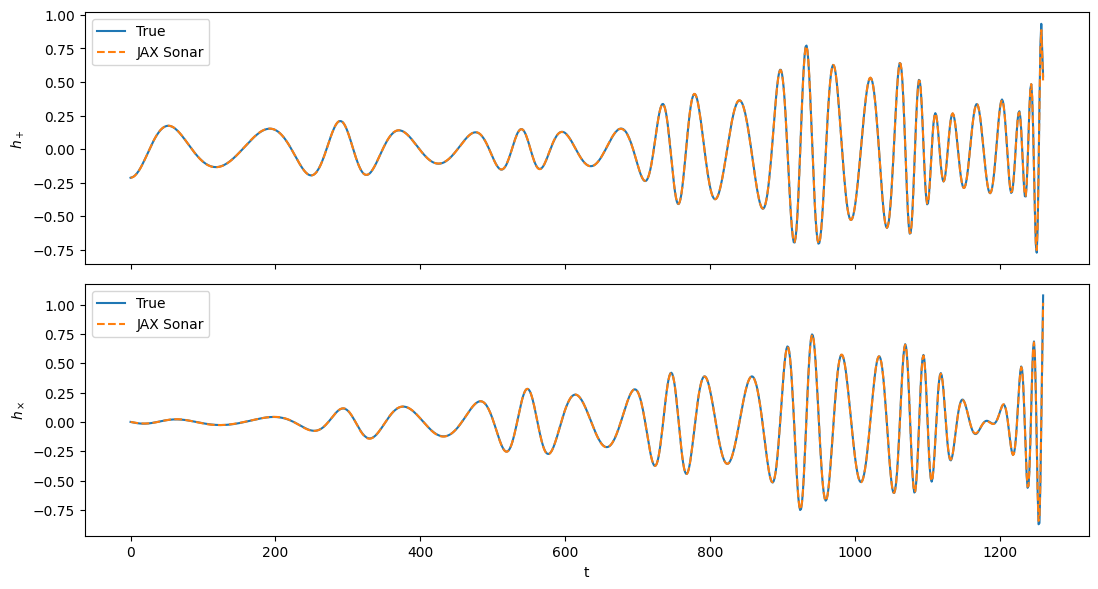

In [ ]:
(final_loss, (final_components, final_roots, final_shell, u0_fit)) = loss_only(
    params, t_full, hp_full, hc_full, LOSS_WEIGHTS
)
final_loss.block_until_ready()
print("final loss:", float(final_loss))
print("raw [waveform, Ricci, frequency, boundary]:", np.asarray(final_components))
print("mean horizon proxy:", float(jnp.mean(final_roots)))

errors = np.asarray(metric_errors_jit(params))
labels = ["g_tt", "g_rr", "g_thth", "g_phph", "g_tph"]
radii = [2, 3, 4, 5, 6, 12, 20]
print("\nMetric relative L2 error across theta (%)")
print("component", *[f"r={r}" for r in radii])
for label, row in zip(labels, errors):
    print(label, *[f"{x:.3f}" for x in row])

trajectory = jax.jit(integrate_network)(
    params["metric"], u0_fit, t_full
)
hp_pred, hc_pred = jax.vmap(
    lambda theta: create_gravityWave(t_full, trajectory, a_true, theta_obs=theta)
)(theta_observed.astype(t_full.dtype))

print("Recovered u0:", np.asarray(u0_fit))
print("True u0:", np.asarray(U0))
print("Mass shell:", float(final_shell))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.asarray(t_full), np.asarray(hp_full[0]), label="True")
axes[0].plot(np.asarray(t_full), np.asarray(hp_pred[0]), "--", label="JAX Sonar")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[1].plot(np.asarray(t_full), np.asarray(hc_full[0]), label="True")
axes[1].plot(np.asarray(t_full), np.asarray(hc_pred[0]), "--", label="JAX Sonar")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("t")
axes[1].legend()
plt.tight_layout()

save_checkpoint(FINAL_PATH, params, len(schedule) - 1, schedule[-1][1] - 1, n, histories)
print("saved:", FINAL_PATH)

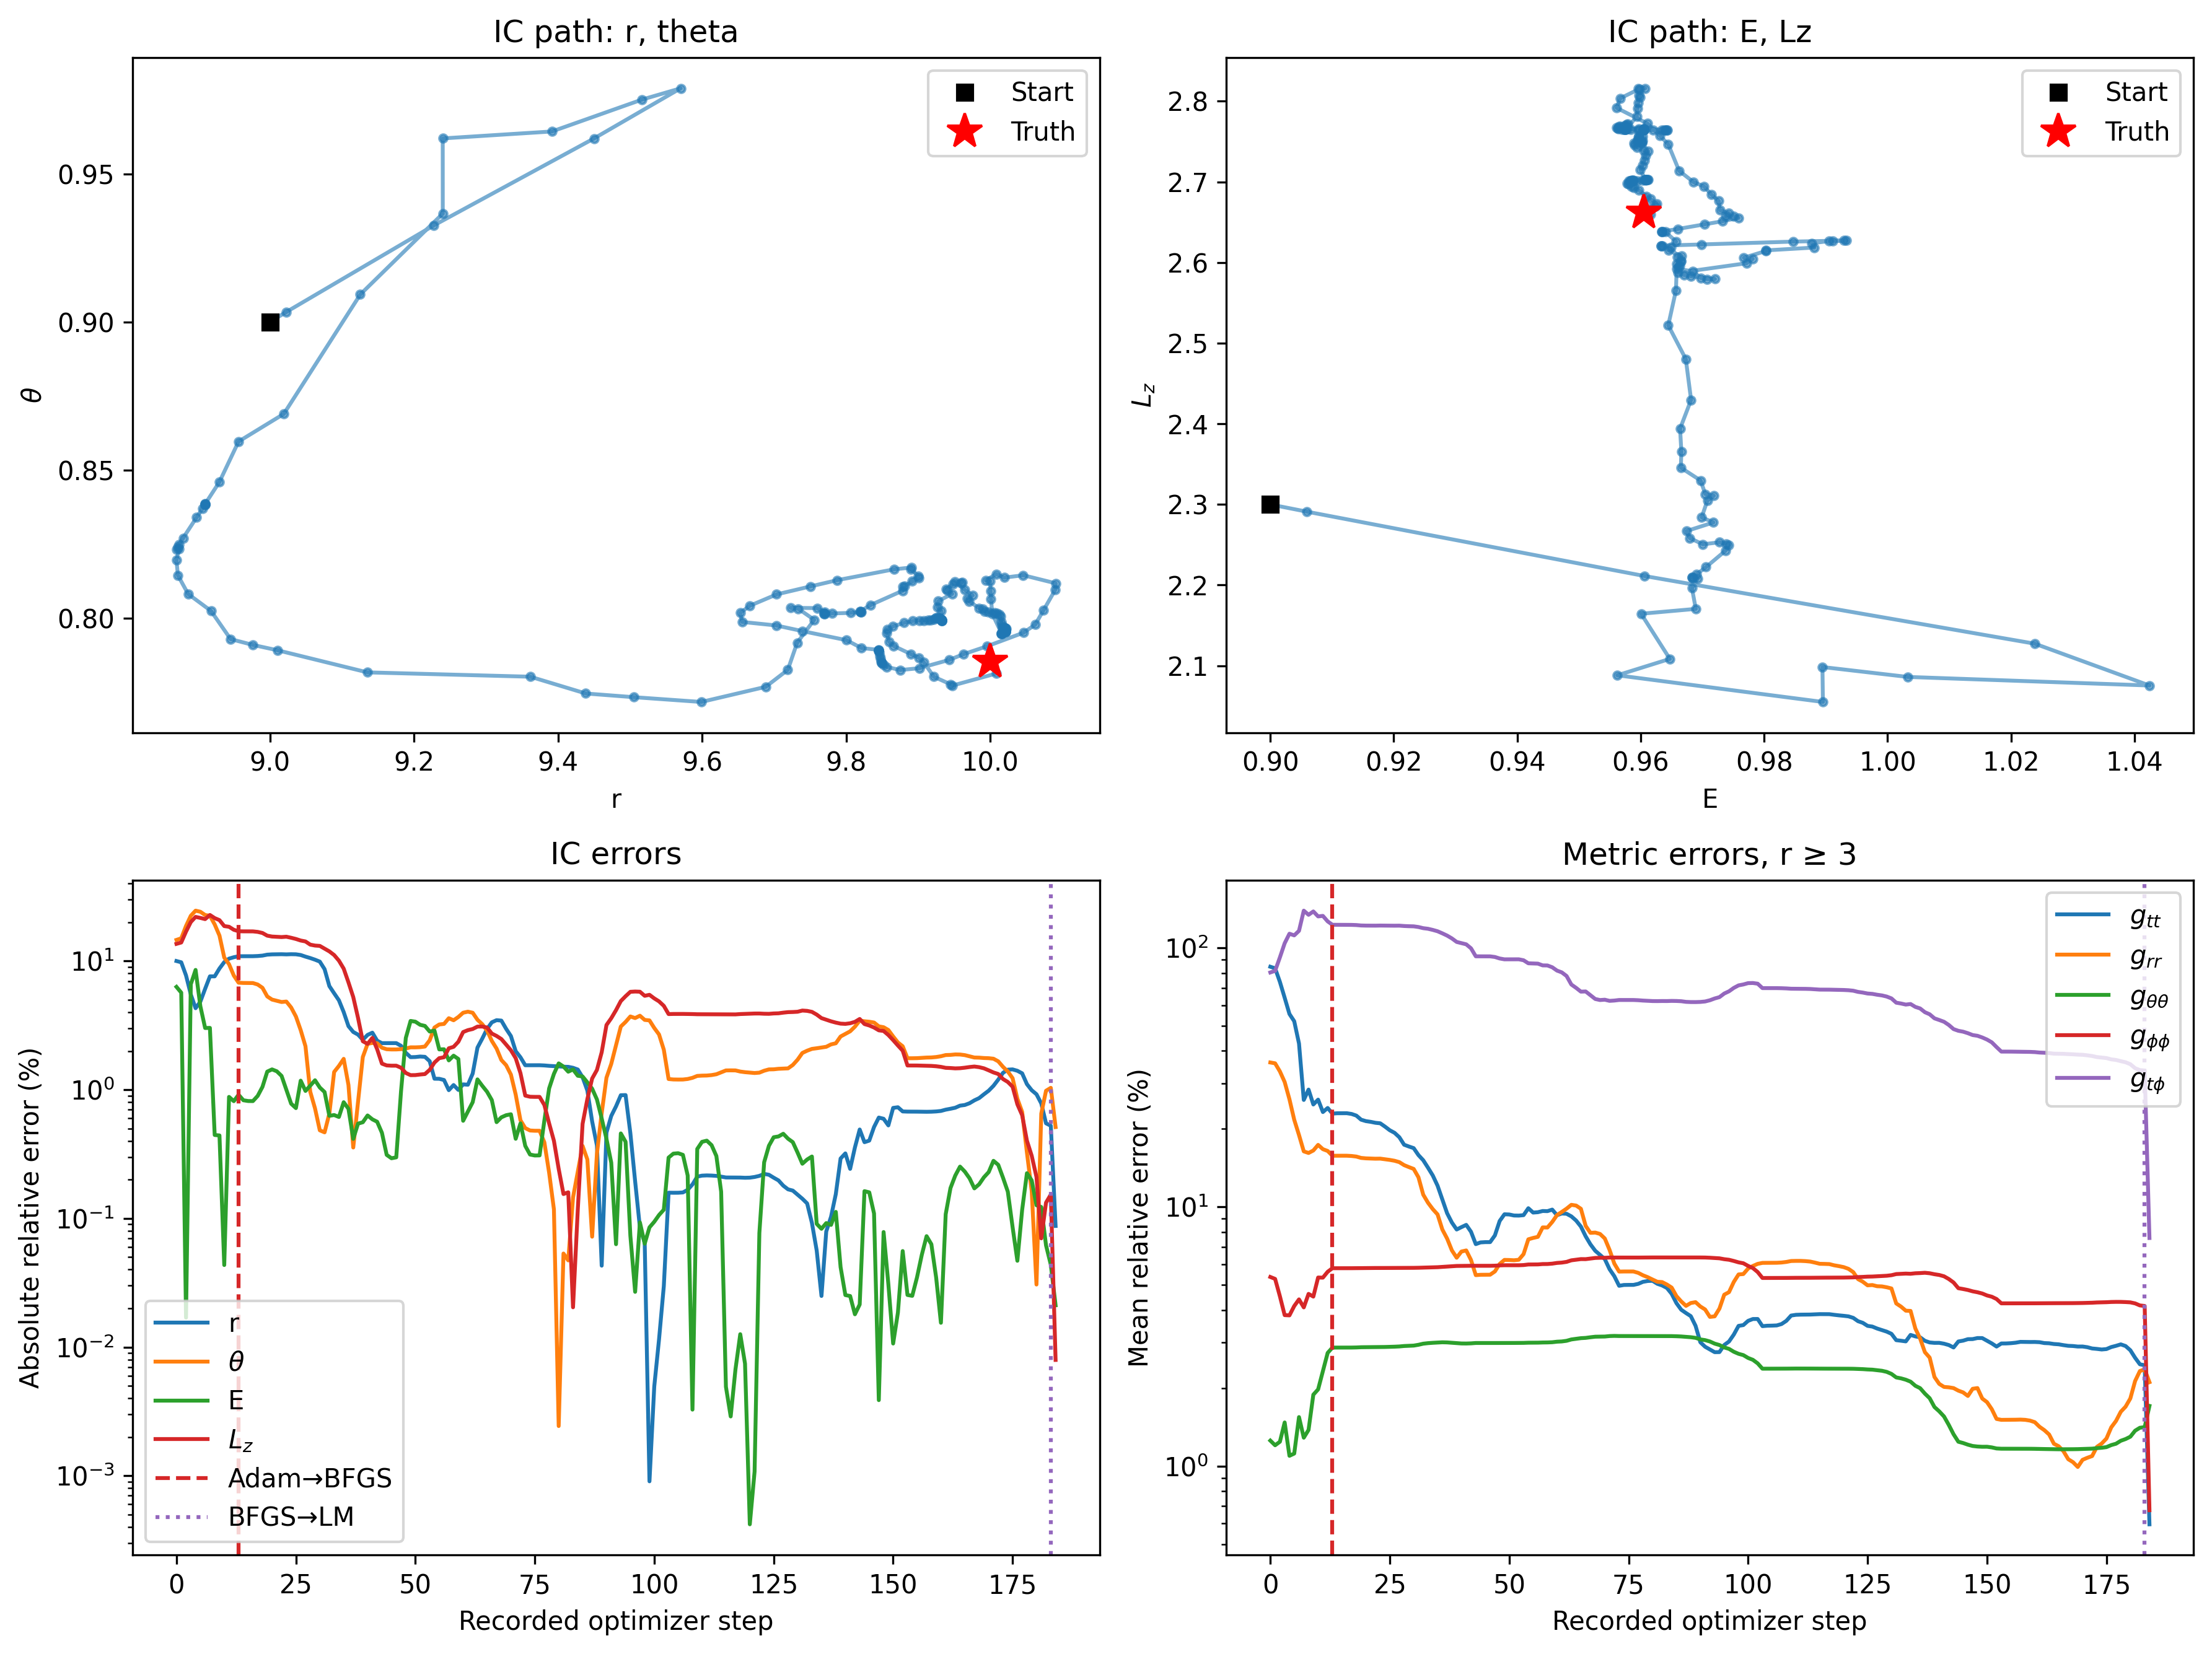

In [ ]:
ic = np.asarray(histories["monitor_ic"])
metric = np.asarray(histories["monitor_metric"])
steps = np.arange(len(ic))

ic_true = np.asarray([
    U0[1],
    U0[2],
    -U0[4],
    U0[7],
], dtype=float)

ic_error = 100 * np.abs((ic - ic_true) / ic_true)
ic_error = np.maximum(ic_error, 1e-12)

metric_labels = [
    r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
    r"$g_{\phi\phi}$", r"$g_{t\phi}$",
]

fig, ax = plt.subplots(2, 2, figsize=(12, 9), dpi = 300)

# r-theta path
ax[0, 0].plot(ic[:, 0], ic[:, 1], ".-", alpha=0.6)
ax[0, 0].plot(ic[0, 0], ic[0, 1], "ks", label="Start")
ax[0, 0].plot(ic_true[0], ic_true[1], "r*", ms=14, label="Truth")
ax[0, 0].set(xlabel="r", ylabel=r"$\theta$", title="IC path: r, theta")
ax[0, 0].legend()

# E-Lz path
ax[0, 1].plot(ic[:, 2], ic[:, 3], ".-", alpha=0.6)
ax[0, 1].plot(ic[0, 2], ic[0, 3], "ks", label="Start")
ax[0, 1].plot(ic_true[2], ic_true[3], "r*", ms=14, label="Truth")
ax[0, 1].set(xlabel="E", ylabel=r"$L_z$", title="IC path: E, Lz")
ax[0, 1].legend()

# IC errors
for i, label in enumerate(["r", r"$\theta$", "E", r"$L_z$"]):
    ax[1, 0].plot(steps, ic_error[:, i], label=label)

ax[1, 0].set_yscale("log")
ax[1, 0].set(
    xlabel="Recorded optimizer step",
    ylabel="Absolute relative error (%)",
    title="IC errors",
)
ax[1, 0].axvline(adam_monitor_end - 1, color="tab:red", ls="--", label="Adam→BFGS")
ax[1, 0].axvline(bfgs_monitor_end - 1, color="tab:purple", ls=":", label="BFGS→LM")
ax[1, 0].legend()

# Metric errors
for i, label in enumerate(metric_labels):
    ax[1, 1].plot(steps, metric[:, i], label=label)

ax[1, 1].set_yscale("log")
ax[1, 1].set(
    xlabel="Recorded optimizer step",
    ylabel="Mean relative error (%)",
    title="Metric errors, r ≥ 3",
)
ax[1, 1].axvline(adam_monitor_end - 1, color="tab:red", ls="--")
ax[1, 1].axvline(bfgs_monitor_end - 1, color="tab:purple", ls=":")
ax[1, 1].legend()

plt.tight_layout()

In [ ]:
def rel_L2(hp, hc):
    true = hp_full[0] + 1j * hc_full[0]
    pred = hp + 1j * hc
    return 100 * jnp.linalg.norm(pred - true) / jnp.linalg.norm(true)

def wave(traj):
    return create_gravityWave(
        t_full, traj, a_true,
        theta_obs=theta_observed[0].astype(t_full.dtype),
    )

u_true = U0.astype(t_full.dtype)
u_fit  = u0_fit.astype(t_full.dtype)

cases = {
    "Kerr metric + true IC":
        wave(jax.jit(integrate_kerr)(u_true, t_full)),

    "Kerr metric + learned IC":
        wave(jax.jit(integrate_kerr)(u_fit, t_full)),

    "Learned metric + true IC":
        wave(jax.jit(integrate_network)(params["metric"], u_true, t_full)),

    "Learned metric + learned IC":
        wave(jax.jit(integrate_network)(params["metric"], u_fit, t_full)),
}

for name, (hp, hc) in cases.items():
    print(f"{name:30s}: {float(rel_L2(hp, hc)):.6f}%")

Kerr metric + true IC         : 0.000000%
Kerr metric + learned IC      : 149.507992%
Learned metric + true IC      : 150.286450%
Learned metric + learned IC   : 1.598623%


# JAX diagnostics

These cells inspect optimizer geometry, local metric–IC distinguishability, spectra, horizon structure, and off-grid metric behavior.


In [ ]:
def report_weighted_gradient_geometry(joint):
    """Gradients of every weighted scalar loss term with respect to all 73 parameters."""
    x, unravel = ravel_pytree(joint)
    weights = LOSS_WEIGHTS.astype(x.dtype)

    def weighted_terms(x_flat):
        trial = unravel(x_flat)
        _, (components, _, shell, _) = loss(
            trial, t_full, hp_full, hc_full, weights
        )
        return jnp.concatenate((
            weights * components,
            jnp.asarray([P_MASS_SHELL * shell], dtype=x.dtype),
        ))

    values = jax.jit(weighted_terms)(x)
    gradients = jax.jit(jax.jacrev(weighted_terms))(x)
    values, gradients = jax.device_get((values, gradients))
    values = np.asarray(values)
    gradients = np.asarray(gradients)

    labels = ["waveform", "Ricci", "frequency", "boundary", "mass shell"]
    norms = np.linalg.norm(gradients, axis=1)
    cosine = gradients @ gradients.T / (
        norms[:, None] * norms[None, :] + 1e-300
    )

    print("Weighted loss and gradient norms")
    for label, value, norm in zip(labels, values, norms):
        print(f"{label:12s} loss={value:.6e}  |grad|={norm:.6e}")

    print("\nPairwise gradient cosines")
    print(" " * 13 + " ".join(f"{x[:5]:>8s}" for x in labels))
    for label, row in zip(labels, cosine):
        print(f"{label:12s} " + " ".join(f"{x:+8.4f}" for x in row))

    return {"labels": labels, "values": values, "gradients": gradients,
            "norms": norms, "cosine": cosine}


def report_lm_jacobian_geometry(lm_result, n_time=None, rank_rtol=1e-10):
    """Use the final LM Jacobian; no second expensive jacfwd call."""
    J = np.asarray(lm_result.jac, dtype=float)
    if n_time is None:
        n_time = hp_full.shape[1]

    n_wave = 2 * hp_full.shape[0] * n_time
    J_wave = J[:n_wave]

    # Derive column ownership from the pytree itself; do not assume dict order.
    marker = tree_util.tree_map(jnp.zeros_like, params)
    marker["ic"] = tree_util.tree_map(jnp.ones_like, params["ic"])
    ic_marker = np.asarray(jax.device_get(ravel_pytree(marker)[0]))
    ic_columns = np.flatnonzero(ic_marker != 0)
    metric_columns = np.flatnonzero(ic_marker == 0)
    J_ic = J_wave[:, ic_columns]
    J_metric = J_wave[:, metric_columns]

    def column_basis(A):
        U, s, _ = np.linalg.svd(A, full_matrices=False)
        rank = int(np.sum(s > rank_rtol * s[0])) if s.size and s[0] > 0 else 0
        return U[:, :rank], s, rank

    Q_ic, s_ic, rank_ic = column_basis(J_ic)
    Q_metric, s_metric, rank_metric = column_basis(J_metric)

    if rank_ic and rank_metric:
        cosines = np.linalg.svd(Q_ic.T @ Q_metric, compute_uv=False)
        angles = np.degrees(np.arccos(np.clip(cosines, 0.0, 1.0)))
        projection = Q_metric @ (Q_metric.T @ J_ic)
        explained = np.linalg.norm(projection) / (np.linalg.norm(J_ic) + 1e-300)
    else:
        angles = np.asarray([])
        explained = float("nan")

    s_full = np.linalg.svd(J, compute_uv=False)
    condition = s_full[0] / s_full[-1] if s_full[-1] > 0 else np.inf

    print("Full residual Jacobian:", J.shape)
    print("Waveform block:", J_wave.shape)
    print("Numerical ranks: IC=", rank_ic, "metric=", rank_metric)
    print("IC–metric principal angles (deg):", angles)
    print("Fraction of IC waveform sensitivity inside metric span:", explained)
    print("Full Jacobian condition number:", condition)
    print("Smallest/full largest singular ratio:", s_full[-1] / s_full[0])

    return {"J": J, "J_wave": J_wave, "angles_deg": angles,
            "ic_explained_fraction": explained, "singular_values": s_full,
            "condition": condition, "rank_ic": rank_ic,
            "rank_metric": rank_metric}


gradient_geometry = report_weighted_gradient_geometry(params)
jacobian_geometry = report_lm_jacobian_geometry(lm_result)


Weighted loss and gradient norms
waveform     loss=2.555596e-04  |grad|=3.284350e+00
Ricci        loss=7.190430e-04  |grad|=1.506699e-02
frequency    loss=1.633329e-04  |grad|=4.504286e-02
boundary     loss=7.352006e-05  |grad|=3.130848e-03
mass shell   loss=1.269991e-06  |grad|=1.067282e-02

Pairwise gradient cosines
                wavef    Ricci    frequ    bound    mass 
waveform      +1.0000  +0.2417  +0.9887  -0.1235  +0.6295
Ricci         +0.2417  +1.0000  +0.3029  +0.0093  +0.0401
frequency     +0.9887  +0.3029  +1.0000  -0.1381  +0.5238
boundary      -0.1235  +0.0093  -0.1381  +1.0000  -0.0240
mass shell    +0.6295  +0.0401  +0.5238  -0.0240  +1.0000
Full residual Jacobian: (4549, 73)
Waveform block: (2000, 73)
Numerical ranks: IC= 4 metric= 58
IC–metric principal angles (deg): [2.31436273e-03 4.95601753e-02 1.73392099e+00 6.26700213e+00]
Fraction of IC waveform sensitivity inside metric span: 0.99999990989285
Full Jacobian condition number: 8185051777.621054
Smallest/full lar

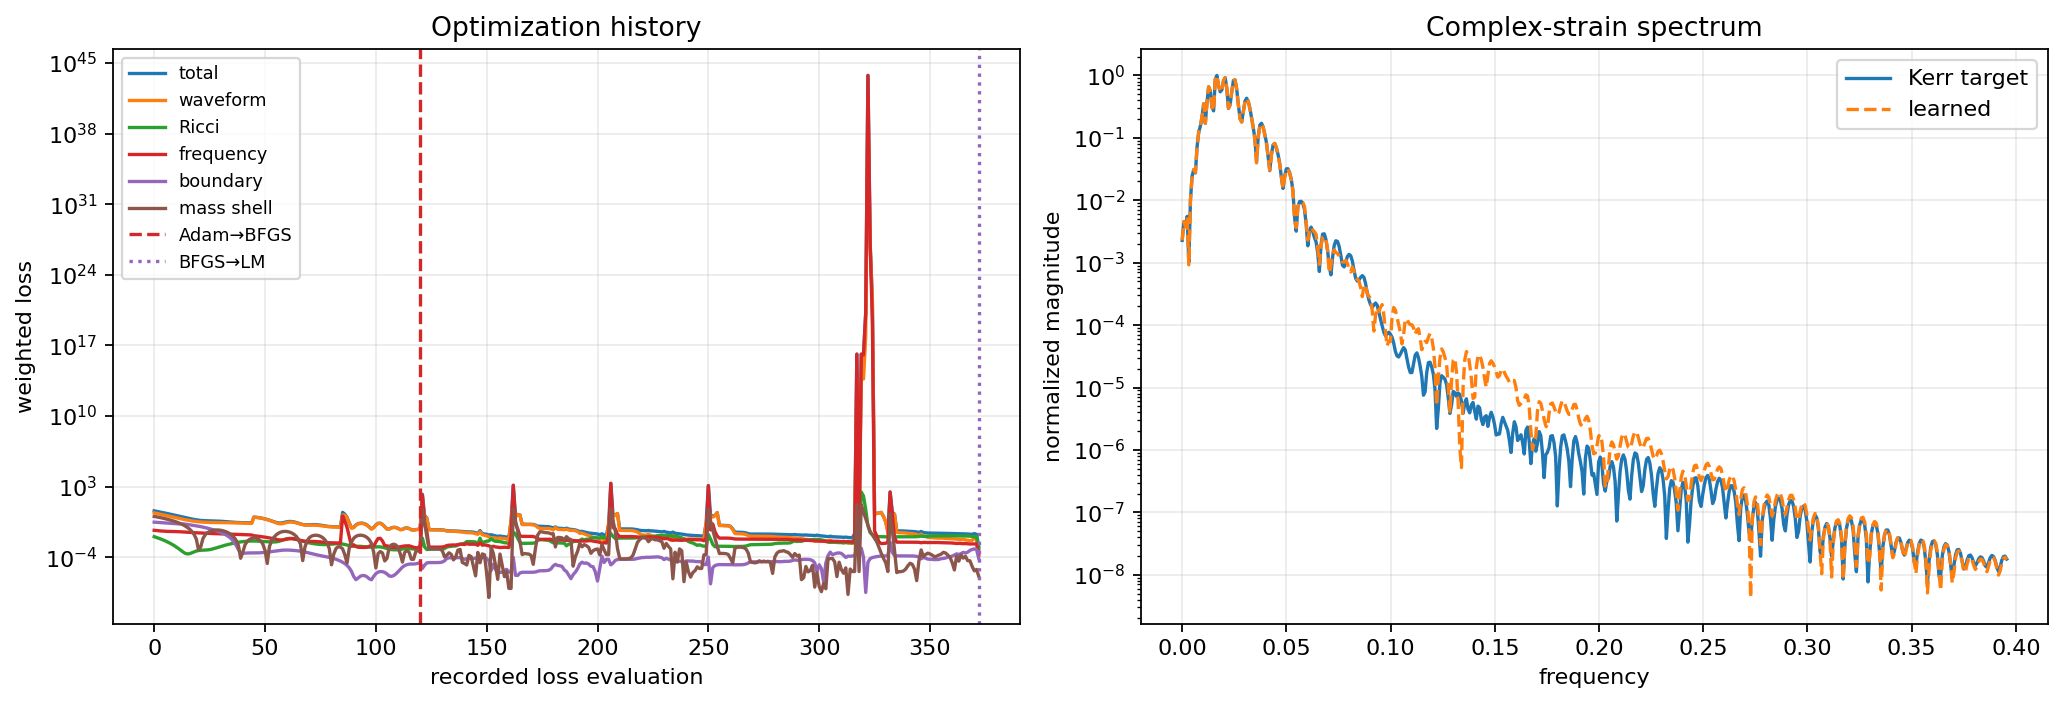

In [ ]:
def plot_training_and_spectrum():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=160)

    for key, label in [
        ("total", "total"),
        ("waveform", "waveform"),
        ("ricci", "Ricci"),
        ("frequency", "frequency"),
        ("boundary", "boundary"),
        ("mass_shell", "mass shell"),
    ]:
        values = np.asarray(histories[key], dtype=float)
        axes[0].semilogy(np.maximum(values, 1e-30), label=label)

    axes[0].axvline(adam_history_end, color="tab:red", ls="--", label="Adam→BFGS")
    axes[0].axvline(bfgs_history_end, color="tab:purple", ls=":", label="BFGS→LM")
    axes[0].set(xlabel="recorded loss evaluation", ylabel="weighted loss",
                title="Optimization history")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    dt = float(t_full[1] - t_full[0])
    h_true = np.asarray(hp_full[0] + 1j * hc_full[0])
    h_learned = np.asarray(hp_pred[0] + 1j * hc_pred[0])
    window = np.hanning(h_true.size)
    freq = np.fft.fftfreq(h_true.size, d=dt)
    positive = freq >= 0
    true_mag = np.abs(np.fft.fft(window * h_true))
    learned_mag = np.abs(np.fft.fft(window * h_learned))
    normalization = max(true_mag.max(), 1e-300)

    axes[1].semilogy(freq[positive], true_mag[positive] / normalization,
                     label="Kerr target")
    axes[1].semilogy(freq[positive], learned_mag[positive] / normalization,
                     "--", label="learned")
    axes[1].set(xlabel="frequency", ylabel="normalized magnitude",
                title="Complex-strain spectrum")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    return fig


training_spectrum_figure = plot_training_and_spectrum()


True Kerr r_+: 1.4358898943540672
Soft-root estimator on exact Kerr: [1.43564665 1.43578763 1.43601218 1.43609606] mean= 1.4358856279547627
Soft roots on learned metric: [1.47525172 1.46157823 1.43226244 1.41569037] mean= 1.4461956913946363

Hard-root and rotation diagnostics
theta       r_H          omega_H      chi2(Omega_Kerr)   roots
 0.15708   1.47373101   0.27295346     -2.744967e-03  1
 0.78540   1.44720785   0.26920652     +3.129839e-03  1
 1.04720   1.43209646   0.26651121     +1.064606e-02  1
 1.57080   1.41553522   0.26321397     +2.282260e-02  1
Hard-root mean: 1.4421426335225003 relative error (%): 0.4354609077631149

Far-field frame dragging
r      theta      omega error (%)    J_eff error (%)
   4    0.78540         1.315442         2.404326
   4    1.04720         0.535968         0.012073
   4    1.57080         2.663365         2.707070
  10    0.78540        12.038126        12.503523
  10    1.04720        10.776271        11.206305
  10    1.57080         9.165887 

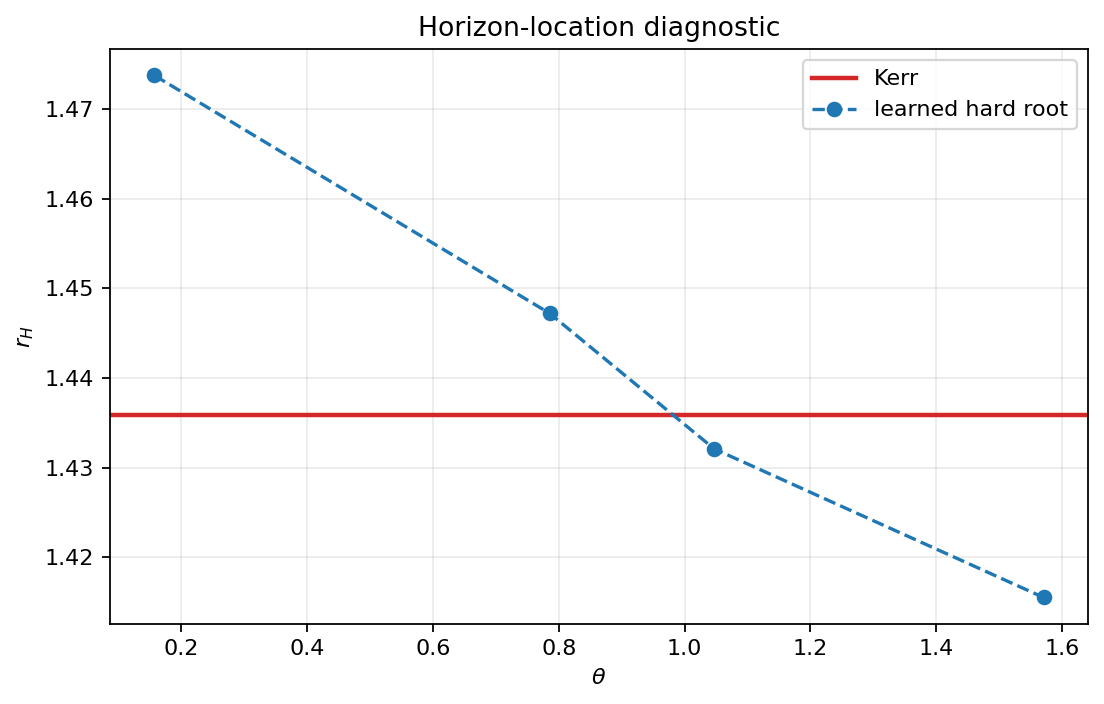

In [ ]:
def horizon_and_rotation_diagnostics(joint, n_r=801):
    metric_params = joint["metric"]
    r_plus = 1.0 + math.sqrt(1.0 - a_true**2)
    omega_true = a_true / (2.0 * r_plus)
    theta_values = np.asarray([math.pi/20, math.pi/4, math.pi/3, math.pi/2])
    radial_grid = np.linspace(1.0, 2.01, n_r)

    def learned_metric(r, theta):
        return np.asarray(jax.device_get(metric_from_network(
            metric_params, jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def kerr_metric(r, theta):
        return np.asarray(jax.device_get(g_Kerr(
            jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def qrr(metric_function, r, theta):
        return 1.0 / metric_function(r, theta)[1, 1]

    def all_roots(metric_function, theta):
        values = np.asarray([qrr(metric_function, r, theta) for r in radial_grid])
        roots = []
        for i in range(radial_grid.size - 1):
            y0, y1 = values[i], values[i + 1]
            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue
            if y0 == 0.0:
                roots.append(float(radial_grid[i]))
            elif y0 * y1 < 0.0:
                roots.append(optimize.brentq(
                    lambda radius: qrr(metric_function, radius, theta),
                    radial_grid[i], radial_grid[i + 1], xtol=1e-12
                ))
        return np.asarray(sorted(set(np.round(roots, 12))), dtype=float)

    def soft_roots(metric_function, tau=1e-4):
        out = []
        r_values = np.asarray(BC_R, dtype=float)
        for theta in np.asarray(BC_THETA, dtype=float):
            q = np.asarray([qrr(metric_function, r, theta) for r in r_values])
            logits = -(q*q) / tau
            logits -= logits.max()
            w = np.exp(logits)
            w /= w.sum()
            out.append(np.sum(w * r_values))
        return np.asarray(out)

    learned_soft = soft_roots(learned_metric)
    kerr_soft = soft_roots(kerr_metric)
    learned_hard = []

    print("True Kerr r_+:", r_plus)
    print("Soft-root estimator on exact Kerr:", kerr_soft,
          "mean=", kerr_soft.mean())
    print("Soft roots on learned metric:", learned_soft,
          "mean=", learned_soft.mean())
    print("\nHard-root and rotation diagnostics")
    print("theta       r_H          omega_H      chi2(Omega_Kerr)   roots")

    for theta in theta_values:
        roots = all_roots(learned_metric, theta)
        root = roots[-1] if roots.size else np.nan
        learned_hard.append(root)
        if np.isfinite(root):
            g = learned_metric(root, theta)
            omega = -g[0, 3] / g[3, 3]
            chi2 = g[0, 0] + 2*omega_true*g[0, 3] + omega_true**2*g[3, 3]
            print(f"{theta:8.5f}  {root:11.8f}  {omega:11.8f}  {chi2:+16.6e}  {roots.size}")
        else:
            print(f"{theta:8.5f}  no root")

    learned_hard = np.asarray(learned_hard)
    finite = np.isfinite(learned_hard)
    if finite.any():
        hard_mean = learned_hard[finite].mean()
        print("Hard-root mean:", hard_mean,
              "relative error (%):", 100*(hard_mean-r_plus)/r_plus)

    print("\nFar-field frame dragging")
    print("r      theta      omega error (%)    J_eff error (%)")
    for radius in (4.0, 10.0, 14.0, 20.0):
        for theta in (math.pi/4, math.pi/3, math.pi/2):
            gn = learned_metric(radius, theta)
            gt = kerr_metric(radius, theta)
            omega_n = -gn[0, 3] / gn[3, 3]
            omega_t = -gt[0, 3] / gt[3, 3]
            jeff_n = -radius * gn[0, 3] / (2*math.sin(theta)**2)
            jeff_t = -radius * gt[0, 3] / (2*math.sin(theta)**2)
            print(f"{radius:4.0f}  {theta:9.5f}  "
                  f"{100*abs(omega_n-omega_t)/(abs(omega_t)+1e-300):15.6f}  "
                  f"{100*abs(jeff_n-jeff_t)/(abs(jeff_t)+1e-300):15.6f}")

    # Exterior signature/determinant check, off the horizon coordinate singularity.
    bad_signature = 0
    nonfinite = 0
    min_abs_det = np.inf
    for radius in np.linspace(2.05, 20.0, 25):
        for theta in np.linspace(math.pi/20, math.pi/2, 9):
            g = learned_metric(radius, theta)
            eig = np.linalg.eigvalsh(g)
            det = np.linalg.det(g)
            if not np.isfinite(g).all() or not np.isfinite(det):
                nonfinite += 1
                continue
            bad_signature += int(np.sum(eig < 0) != 1)
            min_abs_det = min(min_abs_det, abs(det))
    print("\nExterior nonfinite metrics:", nonfinite)
    print("Exterior non-Lorentzian points:", bad_signature)
    print("Minimum |det(g)| on exterior validation grid:", min_abs_det)

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=160)
    ax.axhline(r_plus, color="tab:red", lw=2, label="Kerr")
    ax.plot(theta_values[finite], learned_hard[finite], "o--", label="learned hard root")
    ax.set(xlabel=r"$\theta$", ylabel=r"$r_H$", title="Horizon-location diagnostic")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    return {"r_plus": r_plus, "omega_true": omega_true,
            "kerr_soft": kerr_soft, "learned_soft": learned_soft,
            "theta": theta_values, "learned_hard": learned_hard}


horizon_diagnostics = horizon_and_rotation_diagnostics(params)


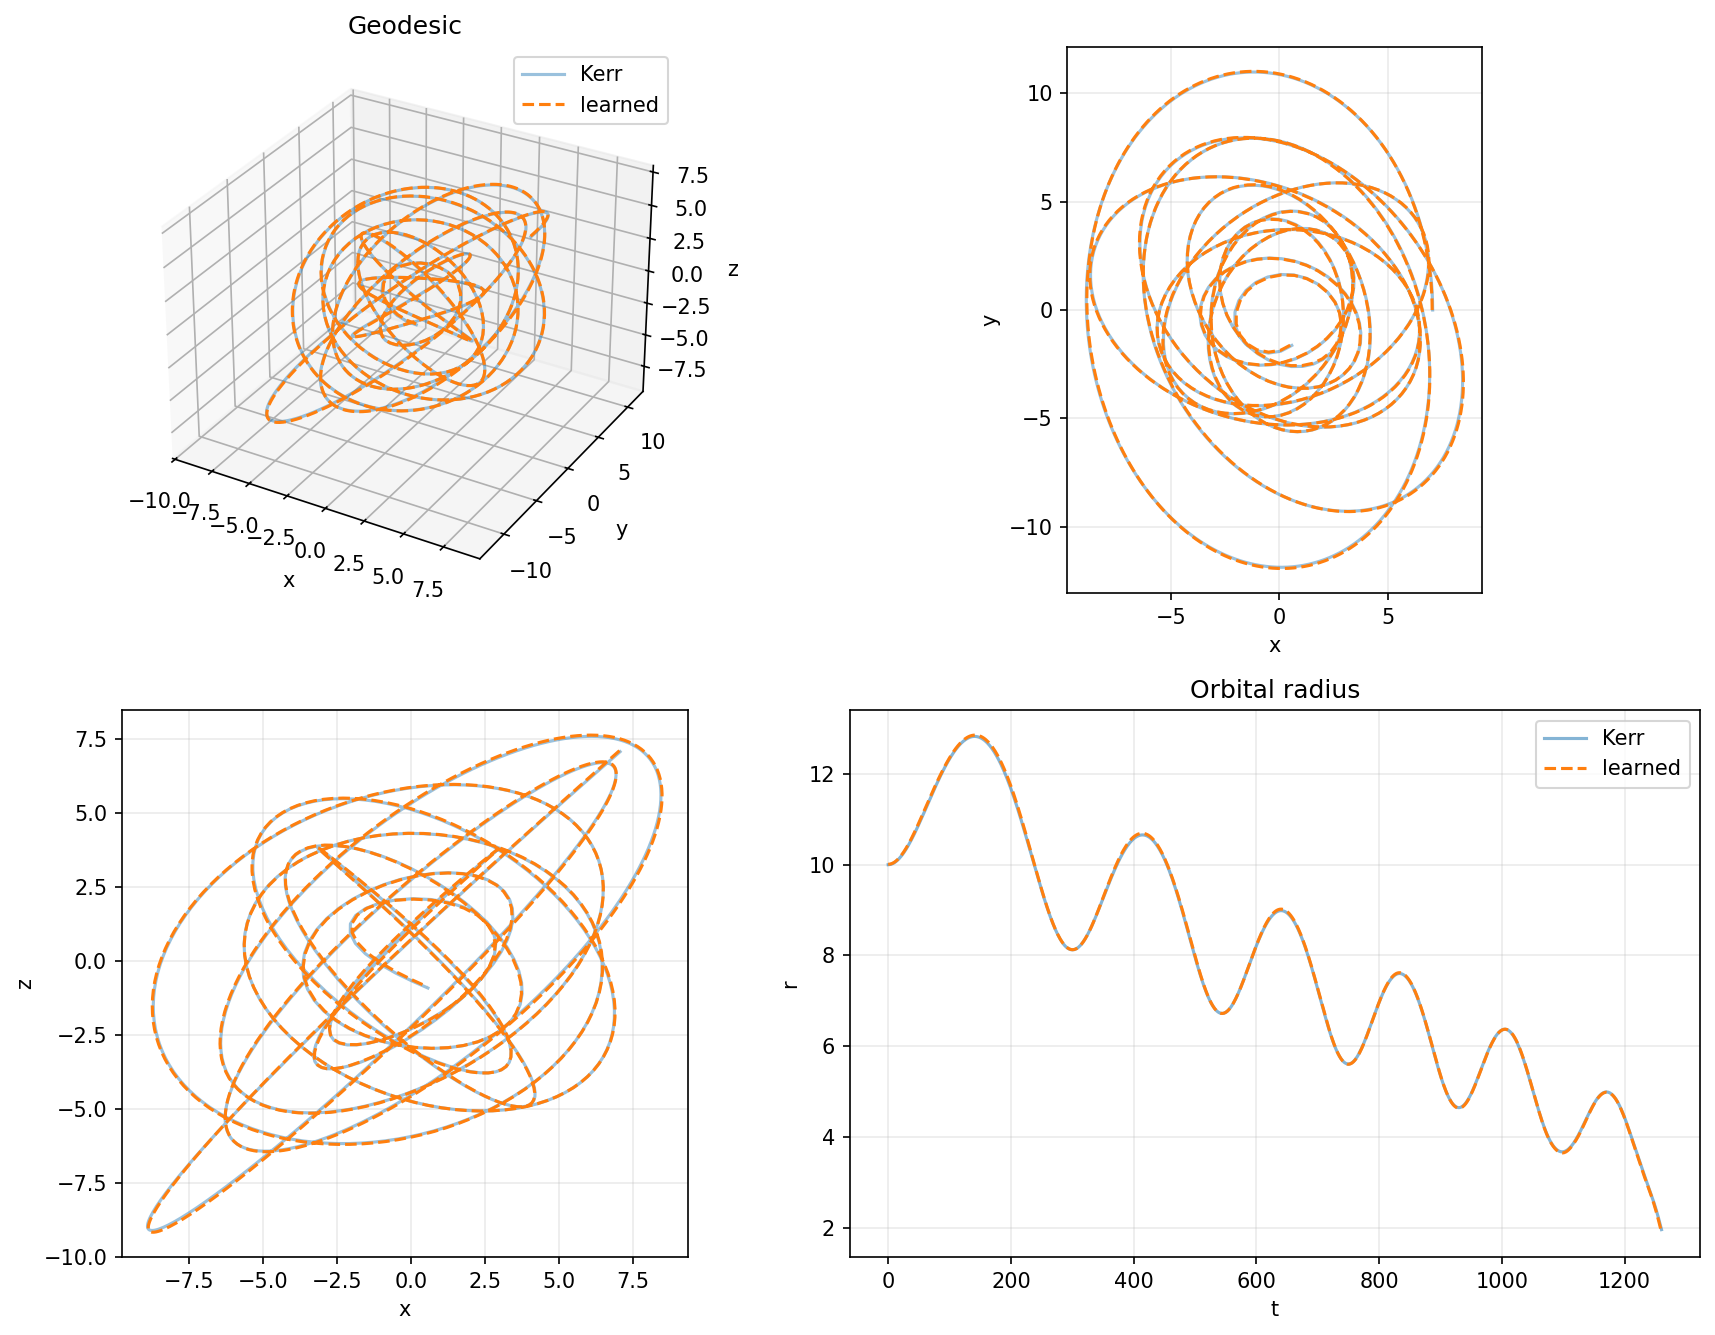

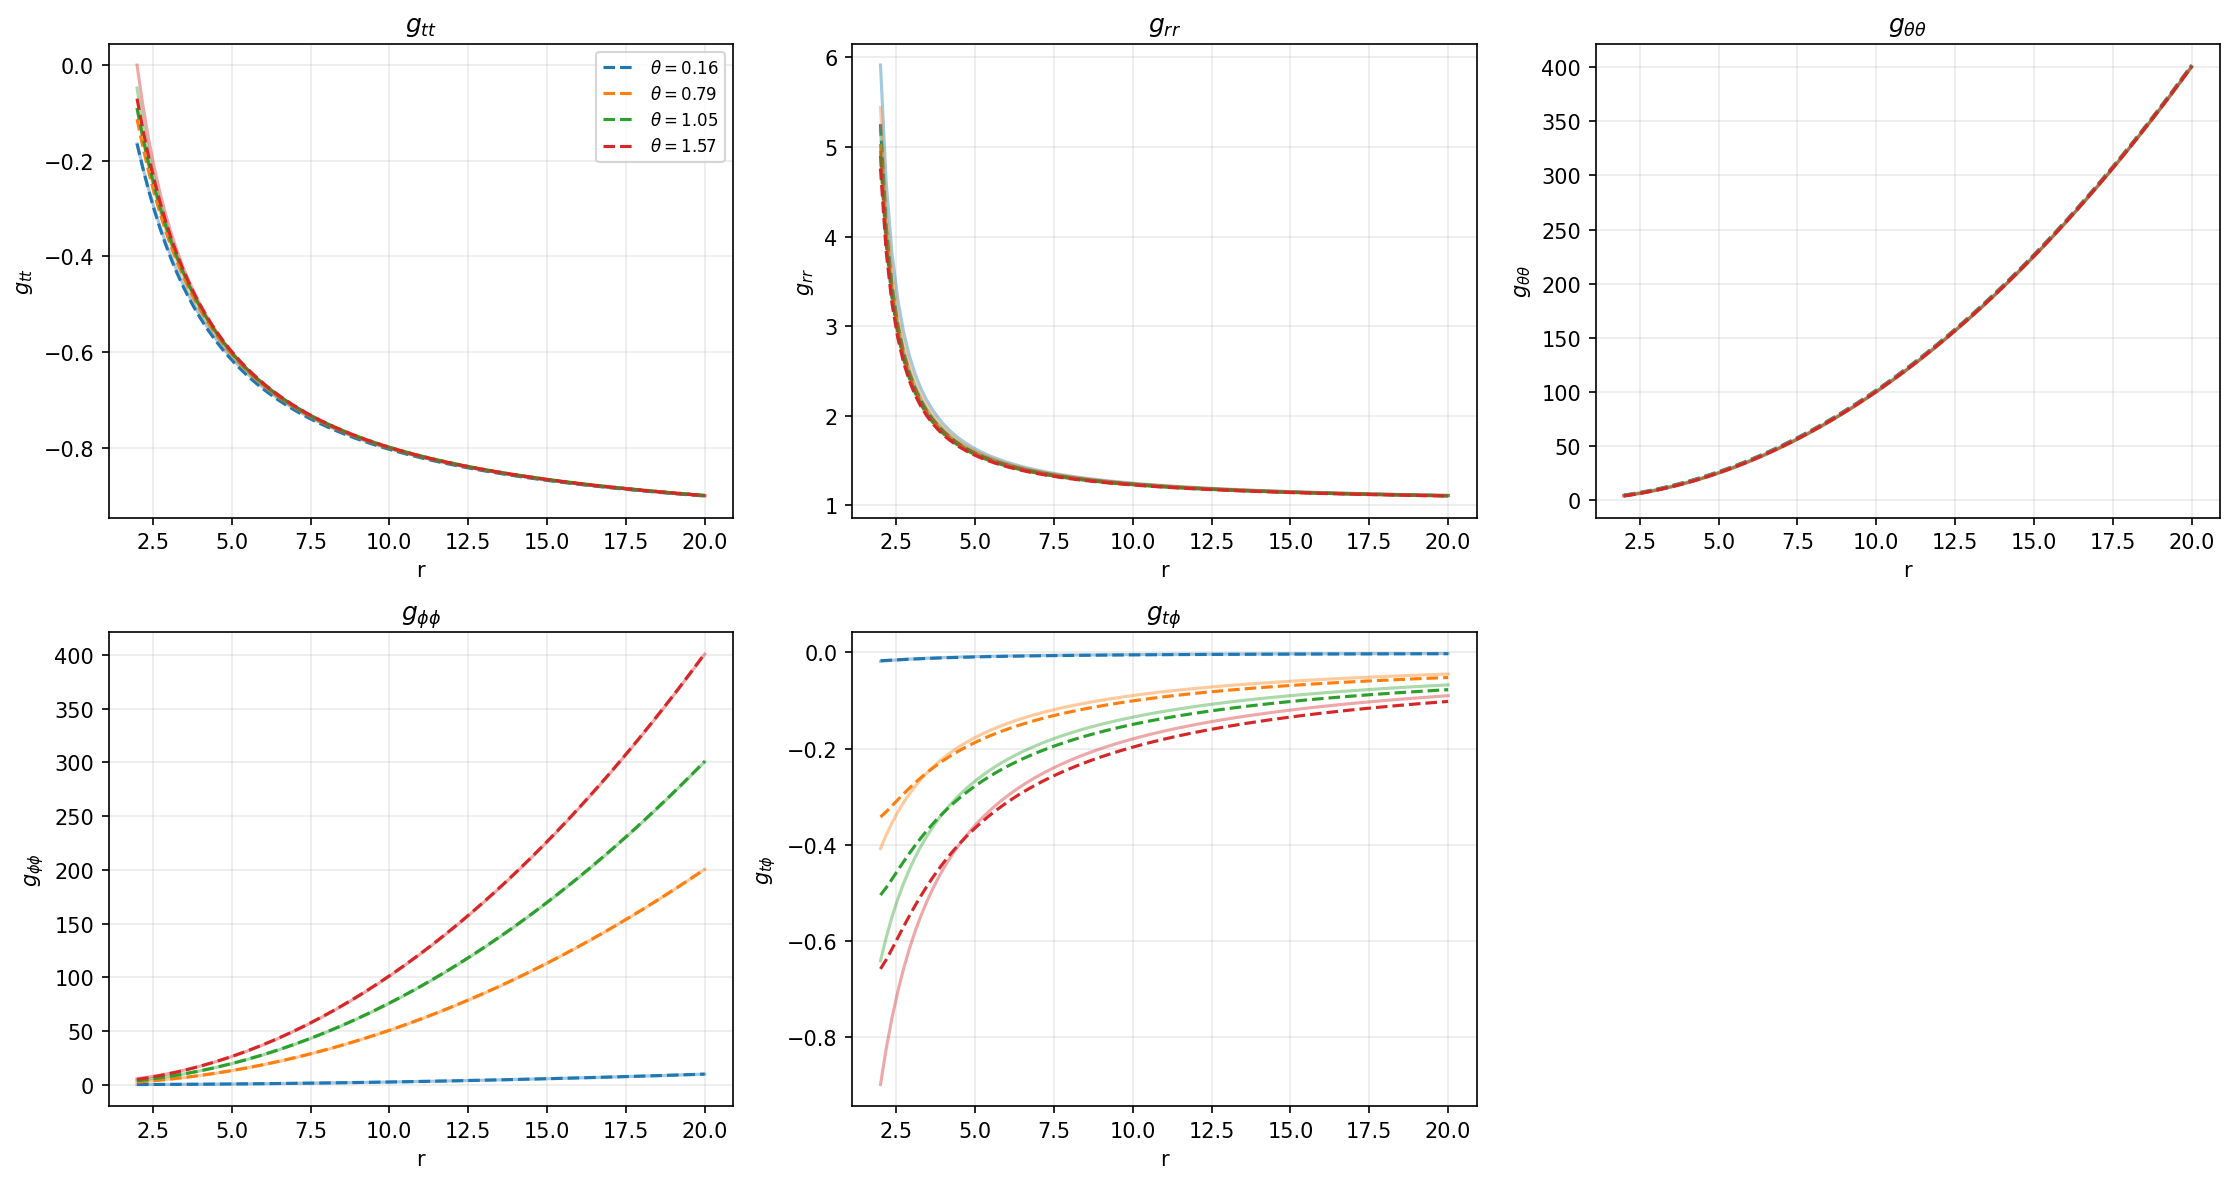

In [ ]:
def plot_orbit_radius_and_metric_profiles(joint, trajectory_true, trajectory_learned):
    true_orbit = np.asarray(jax.device_get(Soln2Orbit(trajectory_true, a_true)))
    learned_orbit = np.asarray(jax.device_get(Soln2Orbit(trajectory_learned, a_true)))
    time_values = np.asarray(jax.device_get(t_full))
    true_traj = np.asarray(jax.device_get(trajectory_true))
    learned_traj = np.asarray(jax.device_get(trajectory_learned))

    fig = plt.figure(figsize=(12, 9), dpi=150)
    ax = fig.add_subplot(221, projection="3d")
    ax.plot(*true_orbit, alpha=0.45, label="Kerr")
    ax.plot(*learned_orbit, "--", label="learned")
    ax.set(xlabel="x", ylabel="y", zlabel="z", title="Geodesic")
    ax.legend()

    for position, i, j, labels in [
        (222, 0, 1, ("x", "y")),
        (223, 0, 2, ("x", "z")),
    ]:
        ax = fig.add_subplot(position)
        ax.plot(true_orbit[i], true_orbit[j], alpha=0.45, label="Kerr")
        ax.plot(learned_orbit[i], learned_orbit[j], "--", label="learned")
        ax.set(xlabel=labels[0], ylabel=labels[1])
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

    ax = fig.add_subplot(224)
    ax.plot(time_values, true_traj[:, 1], alpha=0.55, label="Kerr")
    ax.plot(time_values, learned_traj[:, 1], "--", label="learned")
    ax.set(xlabel="t", ylabel="r", title="Orbital radius")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    indices = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]
    labels = [r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
              r"$g_{\phi\phi}$", r"$g_{t\phi}$"]
    radii = np.linspace(2.0, 20.0, 100)
    thetas = [math.pi/20, math.pi/4, math.pi/3, math.pi/2]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    fig_metric, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150)
    for ax, index, label in zip(axes.flat, indices, labels):
        for theta, color in zip(thetas, colors):
            pred = np.asarray([
                metric_from_network(joint["metric"], r, theta)[index]
                for r in radii
            ], dtype=float)
            true = np.asarray([g_Kerr(r, theta)[index] for r in radii], dtype=float)
            ax.plot(radii, true, color=color, alpha=0.40)
            ax.plot(radii, pred, "--", color=color,
                    label=rf"$\theta={theta:.2f}$")
        ax.set(xlabel="r", ylabel=label, title=label)
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=8)
    axes.flat[-1].axis("off")
    fig_metric.tight_layout()
    return fig, fig_metric


orbit_figure, metric_profile_figure = plot_orbit_radius_and_metric_profiles(
    params, trajectory_gate, trajectory
)


## Runtime notes

- The first LM call compiles a full residual Jacobian. With one observer and 1000 samples it has about 4549 rows and 73 columns.
- The dense matrix is small; differentiating through the orbit and Ricci tensor is the expensive part.
- LM aborts before optimization unless `sum(residual**2)` reproduces the original scalar loss.
- The saved LM checkpoint is separate from the BFGS checkpoints.
- No legacy PyTorch diagnostic objects or global interpolation switches remain.
